# Band plot: a compact dotplot alternative

`scl.bandplot` draws a marker grid where every (gene, group) cell is a **band** — a partly-filled rectangle whose **extent encodes the fraction of expressing cells** and whose **color encodes mean expression**. It generalizes the *band* rendering of `HierarchyRun.marker_map` into a standalone plot with the same `(adata, var_names, groupby)` signature as `scl.dotplot`.

Because a band simply fills part of its cell (instead of a floating dot), rows pack tight — so a band plot stays much shorter than the equivalent dotplot while still showing **both** the fraction and the expression readouts.

Every knob below has a sensible default; a plain call already looks good. This notebook uses a small synthetic PBMC-like dataset so it runs anywhere.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import sceleto as scl

import matplotlib.pyplot as plt

sc.settings.set_figure_params(facecolor='white', frameon=False)
plt.rcParams['pdf.fonttype'] = 42   # keep text editable in exported PDFs

## Data

A small synthetic dataset: 6 PBMC-like cell types, each over-expressing its own marker panel (with `CD3D` deliberately shared by the two T-cell types). `adata.raw` holds the log1p expression that the plot reads by default (`use_raw=True`).

In [2]:
rng = np.random.default_rng(0)

markers_by_ct = {
    'T_CD4': ['CD3D', 'CD4', 'IL7R'],
    'T_CD8': ['CD3D', 'CD8A', 'GZMK'],
    'B':     ['MS4A1', 'CD79A', 'CD19'],
    'NK':    ['NKG7', 'GNLY', 'KLRD1'],
    'Mono':  ['LYZ', 'CD14', 'FCN1'],
    'DC':    ['FCER1A', 'CLEC10A', 'CD1C'],
}
celltypes = list(markers_by_ct)
genes = list(dict.fromkeys(g for gs in markers_by_ct.values() for g in gs))
gidx = {g: i for i, g in enumerate(genes)}

n_per = 400
labels = np.repeat(celltypes, n_per)
X = rng.poisson(0.25, size=(len(labels), len(genes))).astype(float)   # background
for ct, gs in markers_by_ct.items():
    m = labels == ct
    for g in gs:
        X[m, gidx[g]] += rng.poisson(3.0, size=m.sum())              # on-target signal
X = np.log1p(X)

obs = pd.DataFrame({'celltype': pd.Categorical(labels, categories=celltypes)})
adata = ad.AnnData(X=X, obs=obs, var=pd.DataFrame(index=genes))
adata.raw = adata
print(adata)
print('cell types:', celltypes)

AnnData object with n_obs × n_vars = 2400 × 17
    obs: 'celltype'
cell types: ['T_CD4', 'T_CD8', 'B', 'NK', 'Mono', 'DC']


In [3]:
# a flat list  -> one ungrouped column of genes
markers = genes

# a dict       -> the gene axis is split into bracketed blocks (one per cell type)
panel = markers_by_ct

## 1. The default call

No styling needed. Defaults: **genes on the y-axis, groups on the x-axis** (the `marker_map` orientation), band **height** = fraction of expressing cells, band **color** = raw log1p mean expression (`OrRd`). A fraction (band-height) key and an expression colorbar sit on the right.

The block structure is immediately visible: each cell type lights up a tall, dark band on its own markers, and `CD3D` is tall in both T-cell columns.

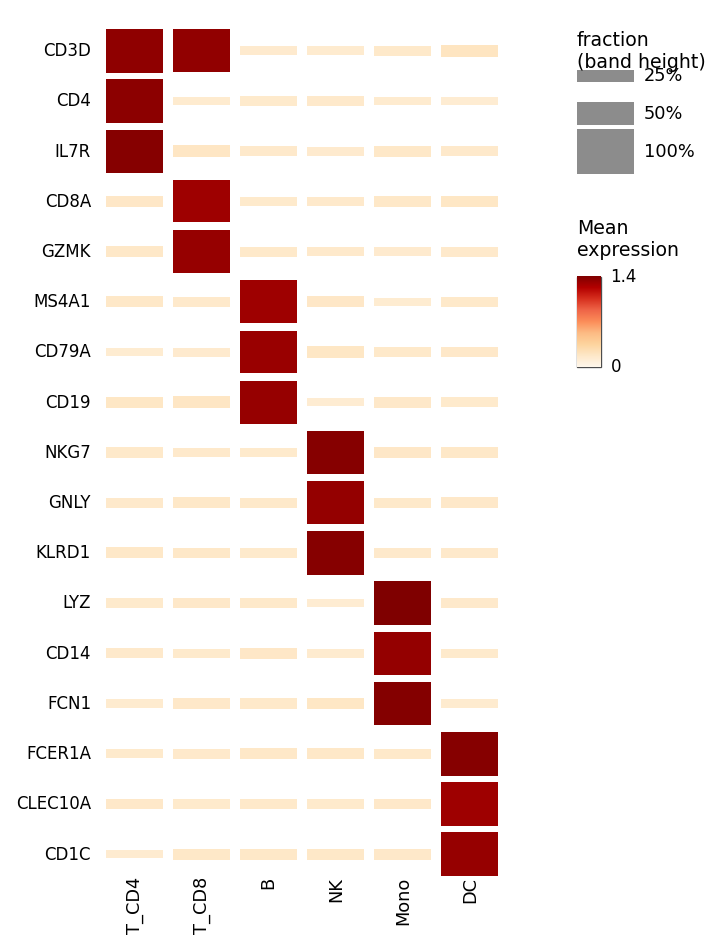

In [4]:
scl.bandplot(adata, markers, 'celltype');

## 2. Orientation

`swap_axes=True` gives the `scanpy.pl.dotplot` orientation — **genes on the x-axis, groups on the y-axis**. The fraction is then encoded as band **width** (the legend updates to say so).

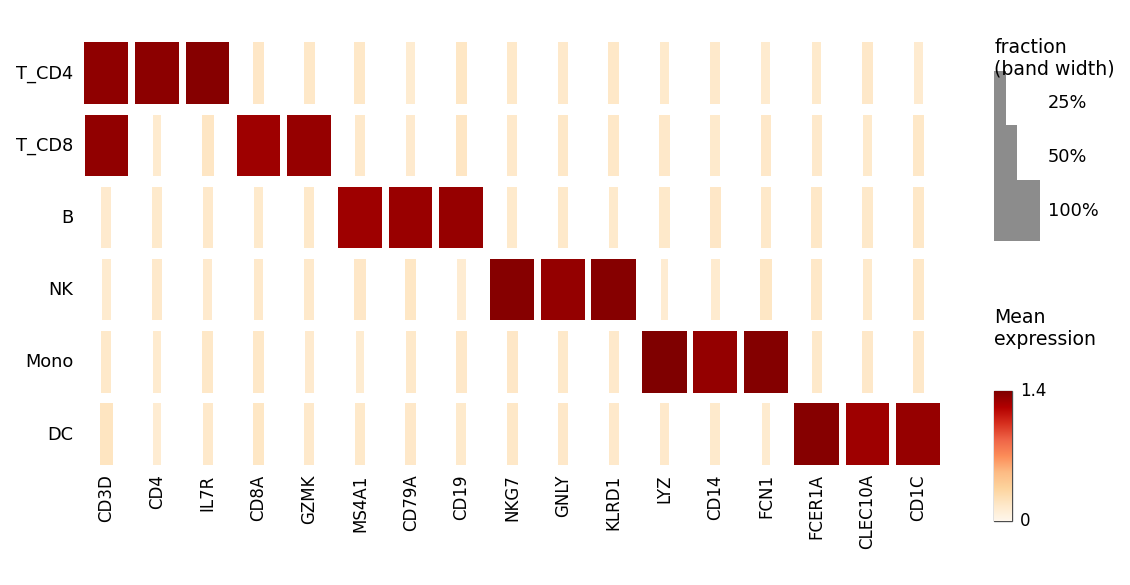

In [5]:
scl.bandplot(adata, markers, 'celltype', swap_axes=True);

## 3. What the color encodes

| argument | color meaning | range |
|---|---|---|
| *(default)* | raw log1p mean expression | `0` .. data max |
| `max_scale=True` | per-gene max-normalised group mean | `0..1` |
| `vmin=`, `vmax=` | clamp the raw-mean color limits | manual |
| `cmap=` | any matplotlib colormap | — |
| `color_floor=` | start the colormap above white so faint-but-present cells stay visible | `0..1` |

With `max_scale=True` each gene is divided by its highest-expressing group, so `vmax=1` is always that group — handy when genes differ a lot in absolute level.

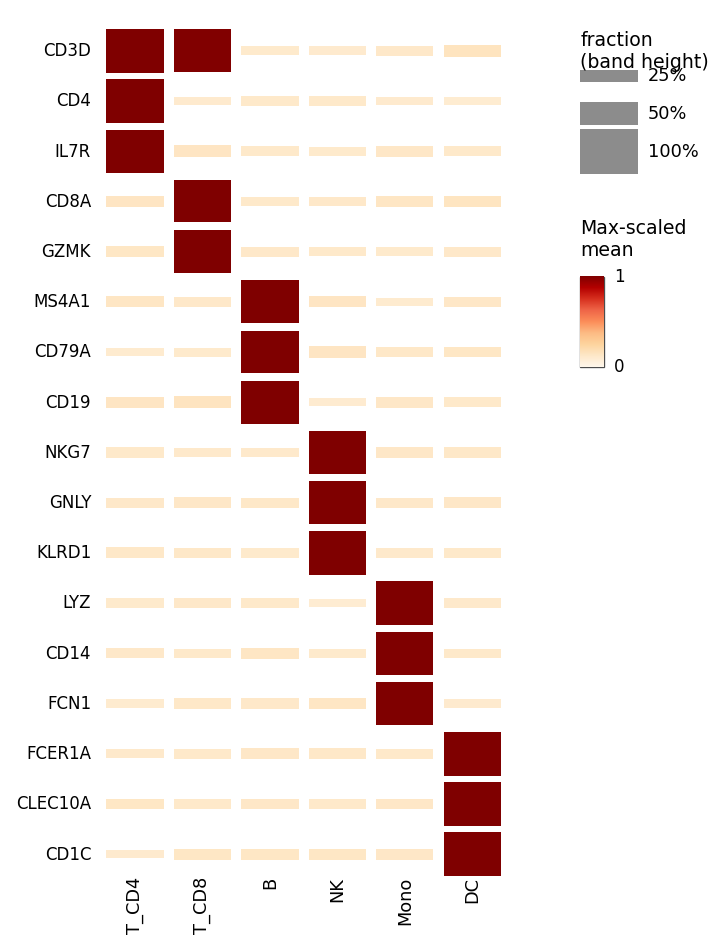

In [6]:
# per-gene max-normalised mean (0..1) -- same scaling as scl.dotplot(max_scale=True)
scl.bandplot(adata, markers, 'celltype', max_scale=True);

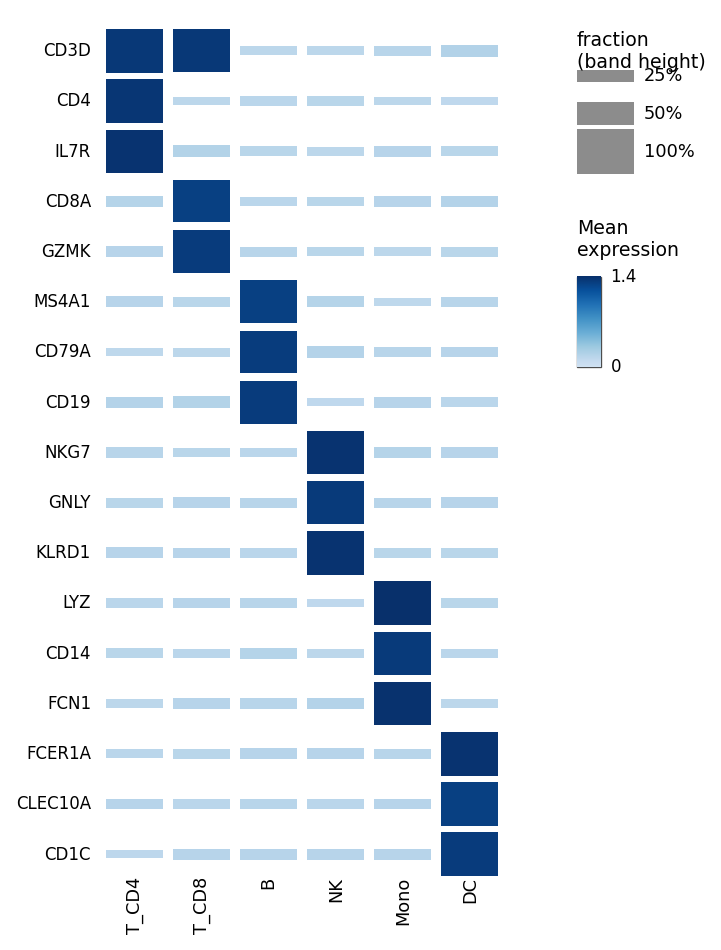

In [7]:
# a different colormap + a color floor so low-but-present bands are not near-white
scl.bandplot(adata, markers, 'celltype', cmap='Blues', color_floor=0.2);

## 4. Bracketed gene groups

Pass a **dict** `{block: [genes]}` to split the gene axis into labelled blocks (a gap + a bracket per block). Genes may repeat across blocks; the first occurrence sets the position.

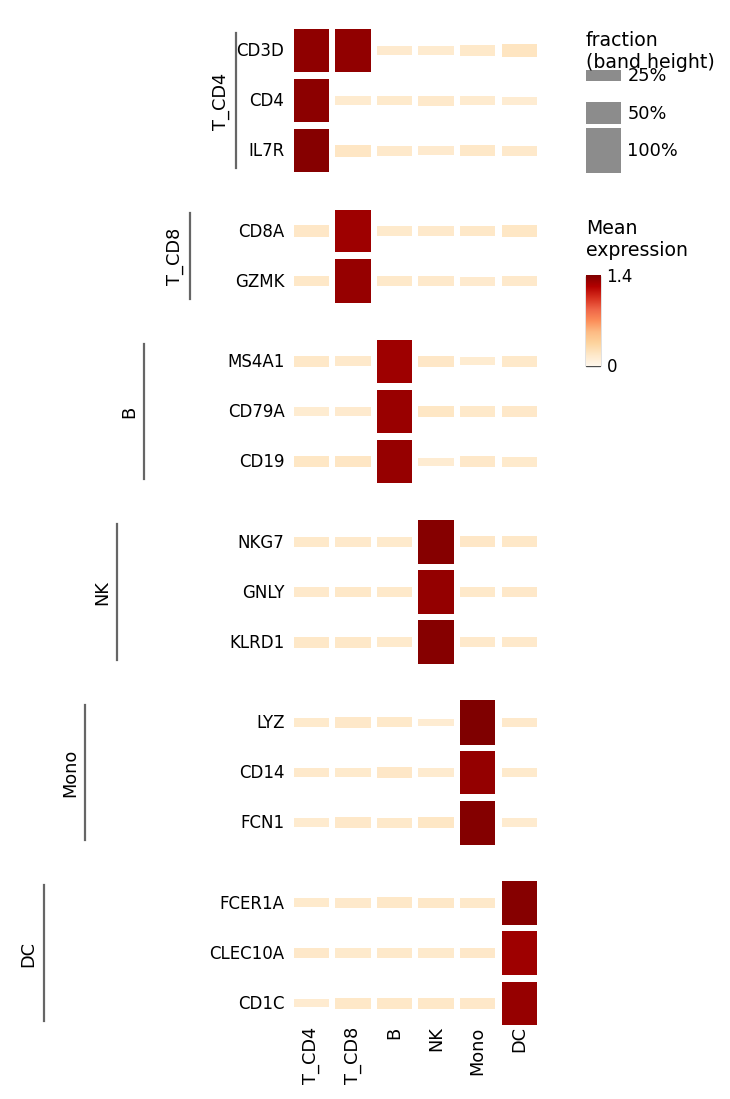

In [8]:
scl.bandplot(adata, panel, 'celltype');

## 5. Band shape & layout

- `band_max` — band extent along the gene axis at fraction = 1 (how tall a fully-expressed band is; default `0.9`)
- `band_w` — fixed band extent along the group axis (band width in the default orientation; default `0.85`)
- `min_frac` — fractions at or below this draw no band
- `group_gap` — extra spacing between bracketed gene blocks
- `figsize` — manual `(width, height)`; auto-sized otherwise

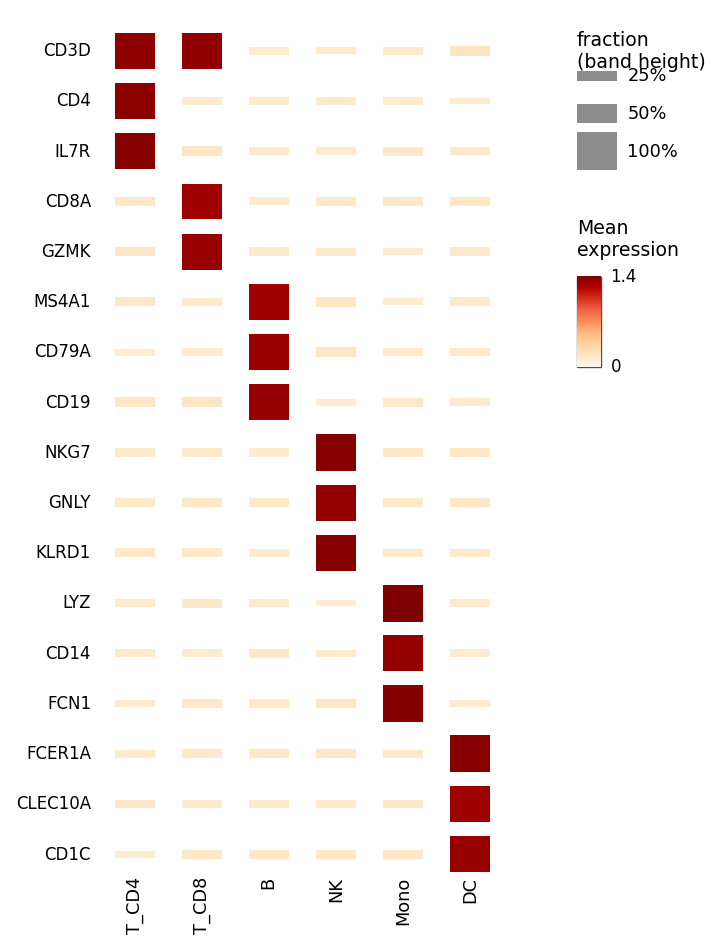

In [9]:
# thinner, shorter bands + hide the faint background bands (frac <= 0.15)
scl.bandplot(adata, markers, 'celltype',
             band_max=0.75, band_w=0.6, min_frac=0.15);

## 6. Subsetting groups

`groups=` restricts and orders the groups shown; `use_raw=False` reads `adata.X` instead of `adata.raw.X`.

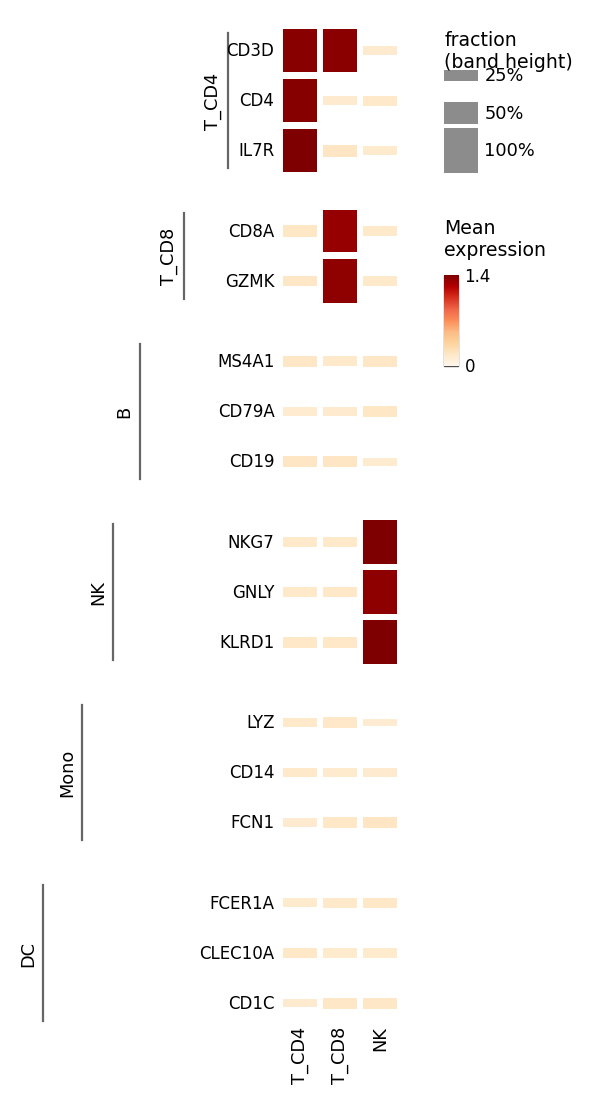

In [10]:
scl.bandplot(adata, panel, 'celltype',
             groups=['T_CD4', 'T_CD8', 'NK']);

## bandplot vs dotplot

The same panel as a dotplot (dot **area** = fraction) and as a band plot (band **height** = fraction). Both read fraction + mean expression; the band plot is the more compact of the two. (`scl.dotplot(swap_axes=True)` puts genes on the y-axis, matching the band plot default.)

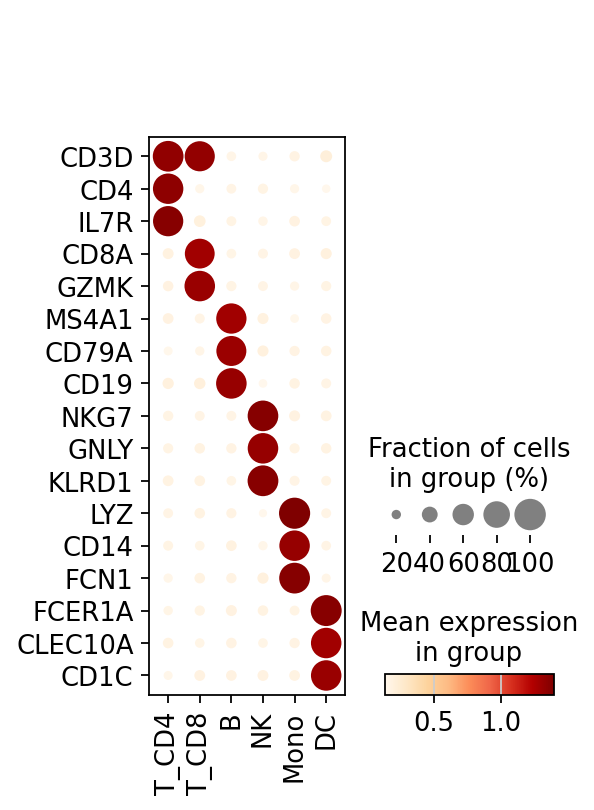

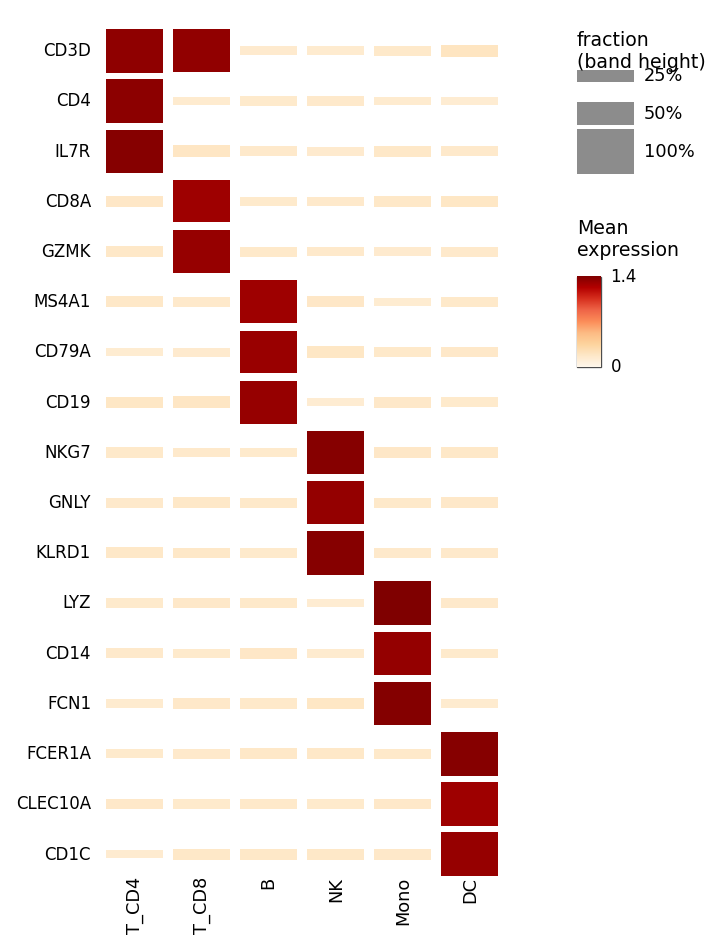

In [11]:
scl.dotplot(adata, markers, 'celltype', swap_axes=True)   # genes on y, groups on x
scl.bandplot(adata, markers, 'celltype');

## Cheat-sheet

| goal | argument |
|---|---|
| dotplot orientation (genes on x) | `swap_axes=True` |
| color = max-scaled 0..1 | `max_scale=True` |
| color limits / colormap | `vmin=`, `vmax=`, `cmap=` |
| keep faint cells visible | `color_floor=0.2` |
| bracketed gene blocks | pass a `dict` `{block: [genes]}` |
| band thickness / height | `band_w=`, `band_max=` |
| hide near-empty cells | `min_frac=` |
| subset / order groups | `groups=[...]` |
| read `adata.X` not `.raw` | `use_raw=False` |
| save a PDF | `save='bandplot.pdf'` |